# Step 4 - Train Embeddings and Stability

                This notebook trains one FastText model per seniority group over multiple seeds and
                saves training metadata for later WEAT and monotonicity analysis.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

SRC_PATH = os.path.abspath("../src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from linkedin_experiment.embeddings import train_group_models

metadata = train_group_models(seeds=[7, 17, 29])
metadata


,group,seed,documents,sentences,token_count,vocab_size,min_count,model_path,vectors_path
0,entry,7,1122,1122,623900,10875,2,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
1,entry,17,1122,1122,623900,10875,2,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
2,entry,29,1122,1122,623900,10875,2,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
3,mid,7,2049,2049,769121,9578,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
4,mid,17,2049,2049,769121,9578,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
5,mid,29,2049,2049,769121,9578,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
6,senior,7,4322,4322,2066579,14904,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
7,senior,17,4322,4322,2066579,14904,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
8,senior,29,4322,4322,2066579,14904,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...
9,leadership,7,2129,2129,1317684,11368,3,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...,D:/Files/UCLA/CLASSES/4th yr/Winter 2026/COMM ...


In [2]:
metadata = pd.read_csv("../results/embeddings/training_metadata.csv")
metadata.groupby("group")[["documents", "token_count", "vocab_size"]].mean()


,documents,token_count,vocab_size
group,,,
entry,1122.0,623900.0,10875.0
leadership,2129.0,1317684.0,11368.0
mid,2049.0,769121.0,9578.0
senior,4322.0,2066579.0,14904.0


## Report Visual Aids

These figures summarize the saved embedding metadata only, so you do not need to retrain models to refresh the visuals.


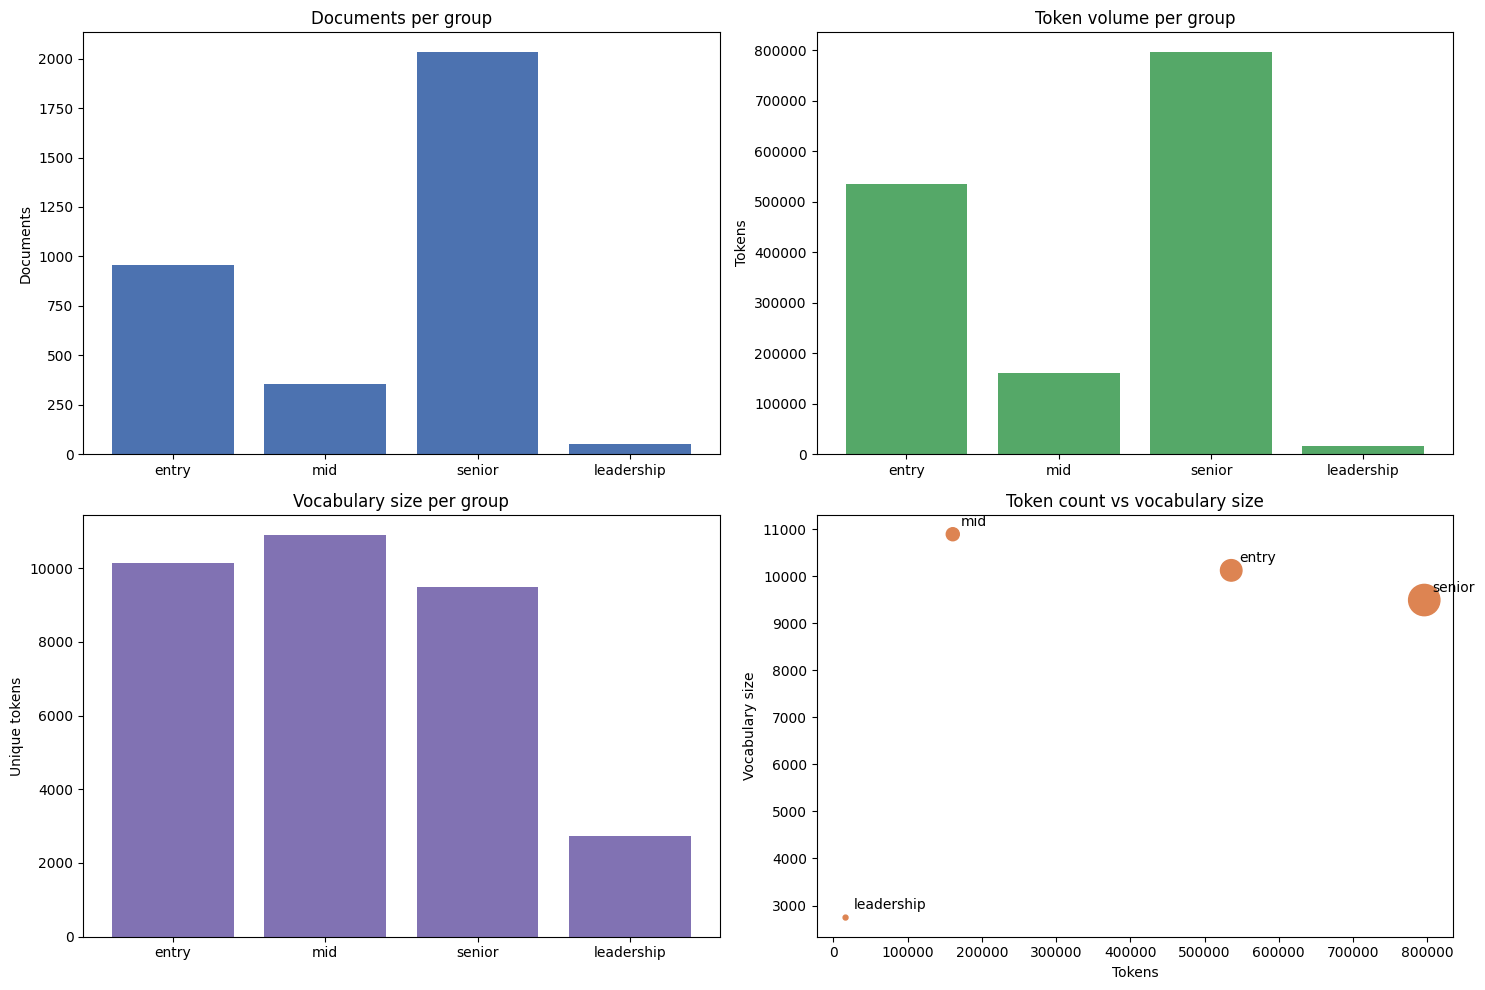

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

group_order = ["entry", "mid", "senior", "leadership"]
metadata = pd.read_csv(Path("../results/embeddings/training_metadata.csv"))
group_summary = (
    metadata.groupby("group", as_index=False)[["documents", "token_count", "vocab_size"]]
    .mean()
    .set_index("group")
    .reindex(group_order)
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(group_summary["group"], group_summary["documents"], color="#4c72b0")
axes[0, 0].set_title("Documents per group")
axes[0, 0].set_ylabel("Documents")

axes[0, 1].bar(group_summary["group"], group_summary["token_count"], color="#55a868")
axes[0, 1].set_title("Token volume per group")
axes[0, 1].set_ylabel("Tokens")

axes[1, 0].bar(group_summary["group"], group_summary["vocab_size"], color="#8172b3")
axes[1, 0].set_title("Vocabulary size per group")
axes[1, 0].set_ylabel("Unique tokens")

axes[1, 1].scatter(
    group_summary["token_count"],
    group_summary["vocab_size"],
    s=group_summary["documents"] / 4,
    color="#dd8452",
)
axes[1, 1].set_title("Token count vs vocabulary size")
axes[1, 1].set_xlabel("Tokens")
axes[1, 1].set_ylabel("Vocabulary size")
for _, row in group_summary.iterrows():
    axes[1, 1].annotate(row["group"], (row["token_count"], row["vocab_size"]), xytext=(6, 6), textcoords="offset points")

plt.tight_layout()
plot_name = "Step 4 - Report Visual Aids"
plt.savefig(f"{plot_name}.png", dpi=300, bbox_inches="tight")
plt.show()
